# Coursera Catalog Exploratory Data Analysis (EDA)

This notebook connects to your Firestore database and performs exploratory data analysis on the `learning_material` collection.

### Objectives:
1. **Specialization count**: Determine how many documents belong to specializations vs. individual courses using the `certificates` field.
2. **Domain/Subdomain distribution**: Extract and analyze the distribution of `domainId` and `subdomainId` values.
3. **Visualization**: Generate charts to visually inspect the distributions.

In [6]:
import os
import sys
from pathlib import Path
from dotenv import load_dotenv
from google.cloud import firestore

# Add backend directory to system path to allow proper imports if needed
sys.path.append(str(Path(os.getcwd()).resolve().parent))

# Load environment variables (GCP project details, etc.)
env_path = Path("backend/.env")
if env_path.exists():
    load_dotenv(dotenv_path=env_path)
    print("Loaded environment from backend/.env")
else:
    print("Warning: backend/.env not found. Using system environment defaults.")

# Initialize Firestore
db_name = os.getenv("FIRESTORE_DATABASE")
if db_name and db_name != "(default)":
    db = firestore.Client(database=db_name)
else:
    db = firestore.Client()

print(f"Connected to Firestore project: {db.project}")

Loaded environment from backend/.env
Connected to Firestore project: z-mentorai


In [7]:
from collections import Counter

col_ref = db.collection("learning_material")

# Safe paginated streaming to prevent gRPC Stream Timeout (504 Deadline Exceeded)
def stream_collection_paginated(col, fields, page_size=2000):
    last_doc = None
    while True:
        query = col.order_by("__name__").select(fields).limit(page_size)
        if last_doc:
            query = query.start_after(last_doc)
        docs = list(query.stream())
        if not docs:
            break
        for doc in docs:
            yield doc
        last_doc = docs[-1]

print("Streaming and aggregating Coursera course details from Firestore...")
course_types = Counter()
domains = Counter()
subdomains = Counter()
languages = Counter()
total_docs = 0
specialization_count = 0

doc_stream = stream_collection_paginated(col_ref, ["course_type", "domain_types", "primary_languages", "certificates"], page_size=2000)

for doc in doc_stream:
    total_docs += 1
    d = doc.to_dict()
    
    # 1. Specialization check via certificates field
    certs = d.get("certificates", [])
    if "Specialization" in certs:
        specialization_count += 1
        
    # 2. Course Type
    course_type = d.get("course_type", "Unknown")
    course_types[course_type] += 1
    
    # 3. Domains and Subdomains
    d_types = d.get("domain_types")
    if d_types:
        for dt in d_types:
            domain_id = dt.get("domainId")
            subdomain_id = dt.get("subdomainId")
            if domain_id:
                domains[domain_id] += 1
            if subdomain_id:
                subdomains[subdomain_id] += 1
                
    # 4. Languages
    langs = d.get("primary_languages", [])
    for lang in langs:
        languages[lang] += 1

print(f"Successfully aggregated {total_docs} documents.")

Streaming and aggregating Coursera course details from Firestore...
Successfully aggregated 17888 documents.


## 1. Specializations vs. Individual Courses

We check the `certificates` list in each document. If `'Specialization'` is present in this list, it represents a course that belongs to a Specialization curriculum; otherwise, it is a standalone (non-specialization) course.

In [8]:
print(f"Total documents analyzed: {total_docs}\n")
print("Course Type Distribution (by Coursera API metadata):")
for c_type, count in course_types.items():
    print(f"- {c_type}: {count} ({count/total_docs*100:.2f}%)")

print("\nSpecialization vs Standalone Course Distribution (by 'certificates' field):")
print(f"- Specialization courses (Specs): {specialization_count} ({specialization_count/total_docs*100:.2f}%)")
print(f"- Standalone courses (Non-Specs): {total_docs - specialization_count} ({(total_docs - specialization_count)/total_docs*100:.2f}%)")

print("\nNOTE: The 'certificates' field determines if a course belongs to a Specialization curriculum. ")
print("If 'Specialization' is in the certificate list, it is part of a specialization; otherwise, it is a standalone course.")

Total documents analyzed: 17888

Course Type Distribution (by Coursera API metadata):
- v2.ondemand: 17796 (99.49%)
- v2.capstone: 92 (0.51%)

Specialization vs Standalone Course Distribution (by 'certificates' field):
- Specialization courses (Specs): 11409 (63.78%)
- Standalone courses (Non-Specs): 6479 (36.22%)

NOTE: The 'certificates' field determines if a course belongs to a Specialization curriculum. 
If 'Specialization' is in the certificate list, it is part of a specialization; otherwise, it is a standalone course.


## 2. Domain & Subdomain Distributions

In [9]:
try:
    import pandas as pd
    
    # Domains dataframe
    df_domains = pd.DataFrame(domains.most_common(), columns=["Domain ID", "Count"])
    df_domains["Percentage (of catalog)"] = (df_domains["Count"] / total_docs * 100).round(2)
    
    # Subdomains dataframe
    df_subdomains = pd.DataFrame(subdomains.most_common(), columns=["Subdomain ID", "Count"])
    df_subdomains["Percentage (of catalog)"] = (df_subdomains["Count"] / total_docs * 100).round(2)
    
    print("=== DOMAIN DISTRIBUTION ===")
    display(df_domains)
    
    print("\n=== TOP 15 SUBDOMAINS DISTRIBUTION ===")
    display(df_subdomains.head(15))
except ImportError:
    print("Pandas is not installed. Printing raw aggregated distributions:\n")
    print("Domains:")
    for k, v in domains.most_common():
        print(f"- {k}: {v} ({v/total_docs*100:.2f}%)")
    print("\nTop 15 Subdomains:")
    for k, v in subdomains.most_common(15):
        print(f"- {k}: {v} ({v/total_docs*100:.2f}%)")

=== DOMAIN DISTRIBUTION ===


,Domain ID,Count,Percentage (of catalog)
0,business,7945,44.42
1,computer-science,7492,41.88
2,information-technology,5577,31.18
3,data-science,4329,24.20
4,life-sciences,1561,8.73
5,physical-science-and-engineering,1342,7.50
6,personal-development,1141,6.38
7,social-sciences,1065,5.95
8,arts-and-humanities,744,4.16
9,math-and-logic,224,1.25



=== TOP 15 SUBDOMAINS DISTRIBUTION ===


,Subdomain ID,Count,Percentage (of catalog)
0,software-development,3563,19.92
1,data-analysis,2407,13.46
2,cloud-computing,2100,11.74
3,leadership-and-management,2088,11.67
4,business-essentials,1901,10.63
5,machine-learning,1575,8.80
6,business-strategy,1353,7.56
7,design-and-product,1253,7.00
8,mobile-and-web-development,1241,6.94
9,personal-development,1141,6.38


## 3. Visualizations

Let's plot the results using matplotlib and seaborn.

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_12140\2779425173.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vals, y=keys, palette="viridis")


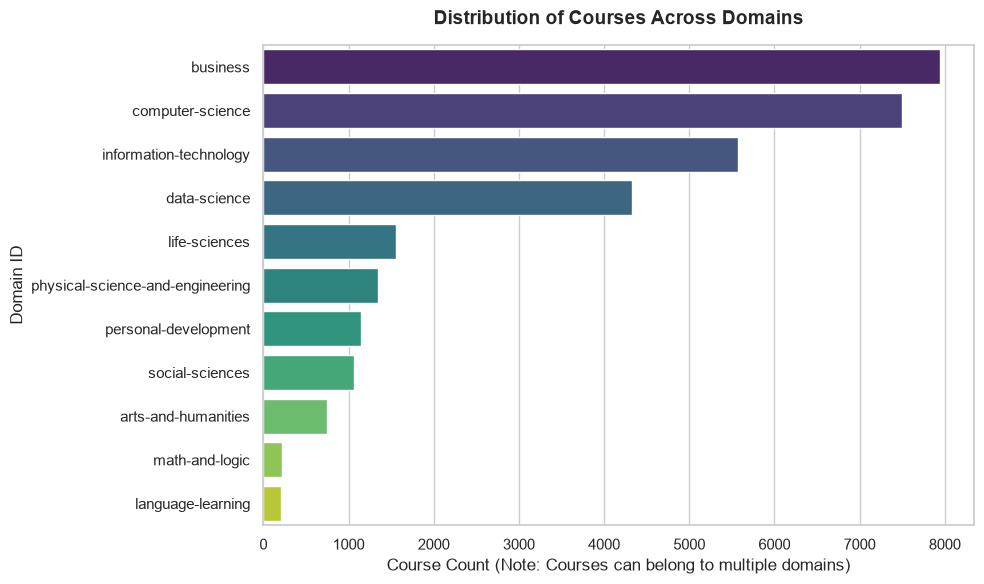

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_12140\2779425173.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sub_vals, y=sub_keys, palette="magma")


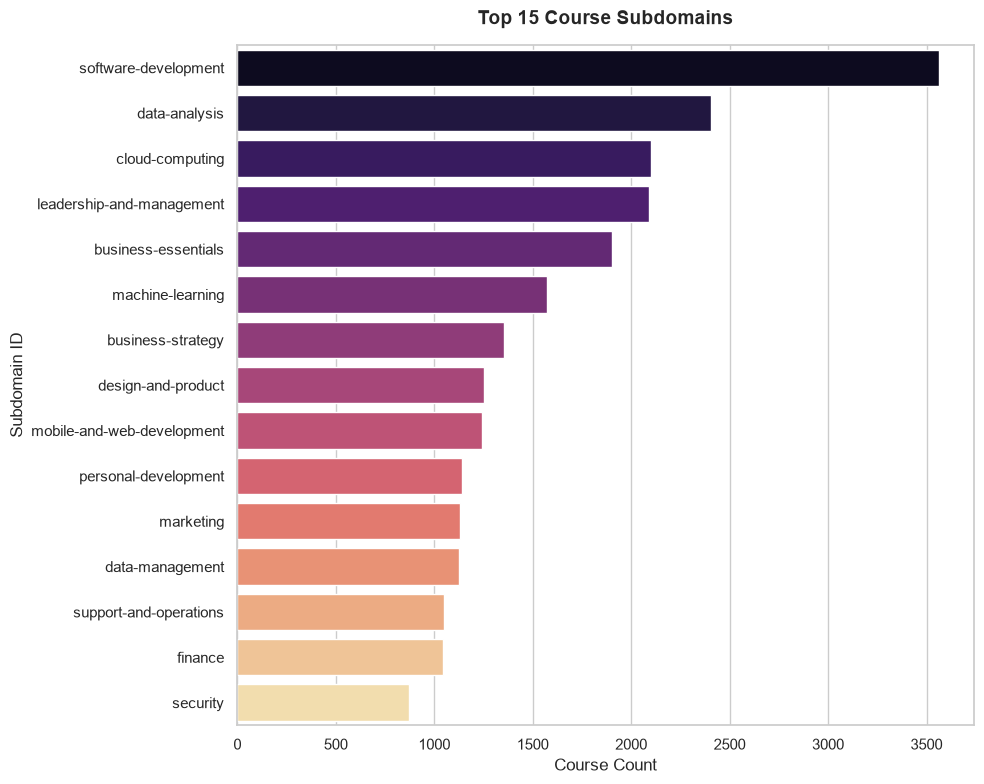

In [10]:
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    sns.set_theme(style="whitegrid")
    
    # 1. Domains Plot
    plt.figure(figsize=(10, 6))
    keys = [k for k, v in domains.most_common()]
    vals = [v for k, v in domains.most_common()]
    sns.barplot(x=vals, y=keys, palette="viridis")
    plt.title("Distribution of Courses Across Domains", fontsize=14, fontweight="bold", pad=15)
    plt.xlabel("Course Count (Note: Courses can belong to multiple domains)", fontsize=12)
    plt.ylabel("Domain ID", fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # 2. Subdomains Plot (Top 15)
    plt.figure(figsize=(10, 8))
    sub_keys = [k for k, v in subdomains.most_common(15)]
    sub_vals = [v for k, v in subdomains.most_common(15)]
    sns.barplot(x=sub_vals, y=sub_keys, palette="magma")
    plt.title("Top 15 Course Subdomains", fontsize=14, fontweight="bold", pad=15)
    plt.xlabel("Course Count", fontsize=12)
    plt.ylabel("Subdomain ID", fontsize=12)
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("matplotlib or seaborn is not installed. Visualizations skipped.")
    print("To enable plots, run: pip install matplotlib seaborn")